In [1]:
# All the imports

import torch
from torch.utils.data import TensorDataset
from torch import nn
import matplotlib.pyplot as plt
import argparse

from the_ml.load_dataset import labelList, get_data
from the_ml.preprocess import preprocess_dataset
from the_ml import bigmodel

from ml_util.eeg_util import plotEEG
from ml_util.checkpoint import checkpoint
from ml_util.data_module import DataModule
from ml_util.trainer import GoodClassificationModel, GoodTrainer
from ml_util.logger import WandBLogger, print_stats, HistoryLogger
from ml_util.reporter import getTestResults
from ml_util.plot import plot_loss_acc, plot_confusion_matrix, plot3D, write_test_acc

# To make it reproducible
torch.manual_seed(42)

/Users/ulyssedurand/git/eeg-ml/EEG-classification/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Arguments

verbose = True
hyperparams = {
    "bands": "five",
    "lr": 1e-3,
    "weight_decay": 7e-2,
    "batch_size": 128,
    "epochs": 1000
}

In [3]:
print("Loading raw dataset")
X_raw, y = checkpoint(lambda: get_data(verbose=True), "raw_input")
print(f"Raw input dataset size: {X_raw.shape}")

Loading raw dataset
Raw input dataset size: torch.Size([480, 32, 3200])


# The SAM40 Dataset

It consists of electroencephalograms (EEG) of people while they perform tasks.

You can find the dataset [here](https://figshare.com/articles/dataset/SAM_40_Dataset_of_40_Subject_EEG_Recordings_to_Monitor_the_Induced-Stress_while_performing_Stroop_Color-Word_Test_Arithmetic_Task_and_Mirror_Image_Recognition_Task/14562090)

We extract the dataset to obtain 480 samples (120 for each task among Stroop, Relax, Mirror_Image, and Arithmetic).
Each sample has the record of the 32 electrods of the EEG over 25 seconds at 128Hz (3200 points)

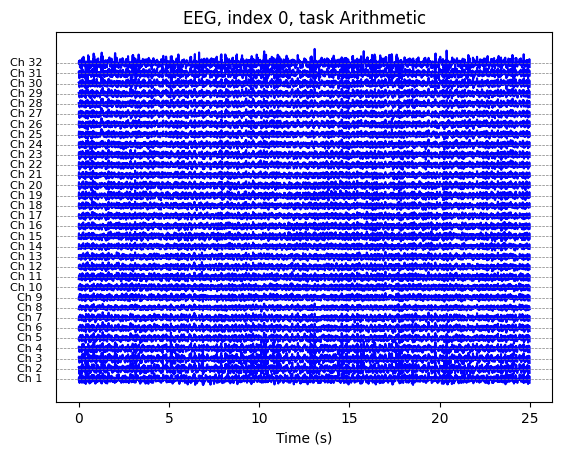

In [4]:
if verbose:
    plotEEG(X_raw[0], title=f"EEG, index 0, task {labelList[y[0]]}", fileName=f"fig/EEG_sample_example.png")

## Preprocessing

We don't want to feed the raw inputs to our model, we will extract features from it.

The approach used was to use a time-frequency spectrogram with the alpha, beta, gamma, delta and theta bands (those are intervals in the frequency domain).

After the preprocessing step we have a 32 channels 5x101 image for each sample. 5 corresponds to the 5 frequency intervals and 101 are the time intervals.

In [5]:
# Applies preprocessing
print("Preprocessing input data")
X = checkpoint(lambda : preprocess_dataset(X_raw, hyperparams["bands"], verbose=True), "preprocessed")
print(f"Preprocessed input dataset shape: {X.shape}")

# Stores in a TensorDataset
dataset = DataModule(X, y, val_part=0.15, test_part=0.15)

# Uncomment to reduce the size of the dataset
# dataset = dataset.get_part(0.1)

Preprocessing input data
Preprocessed input dataset shape: torch.Size([480, 32, 5, 101])


<Figure size 640x480 with 0 Axes>

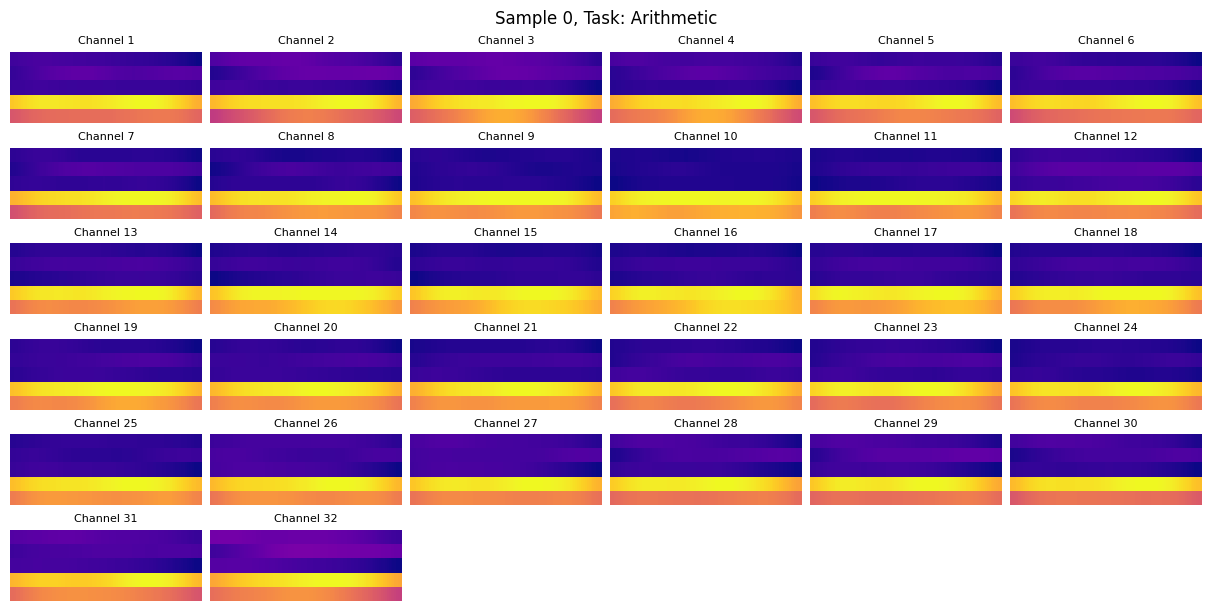

<Figure size 640x480 with 0 Axes>

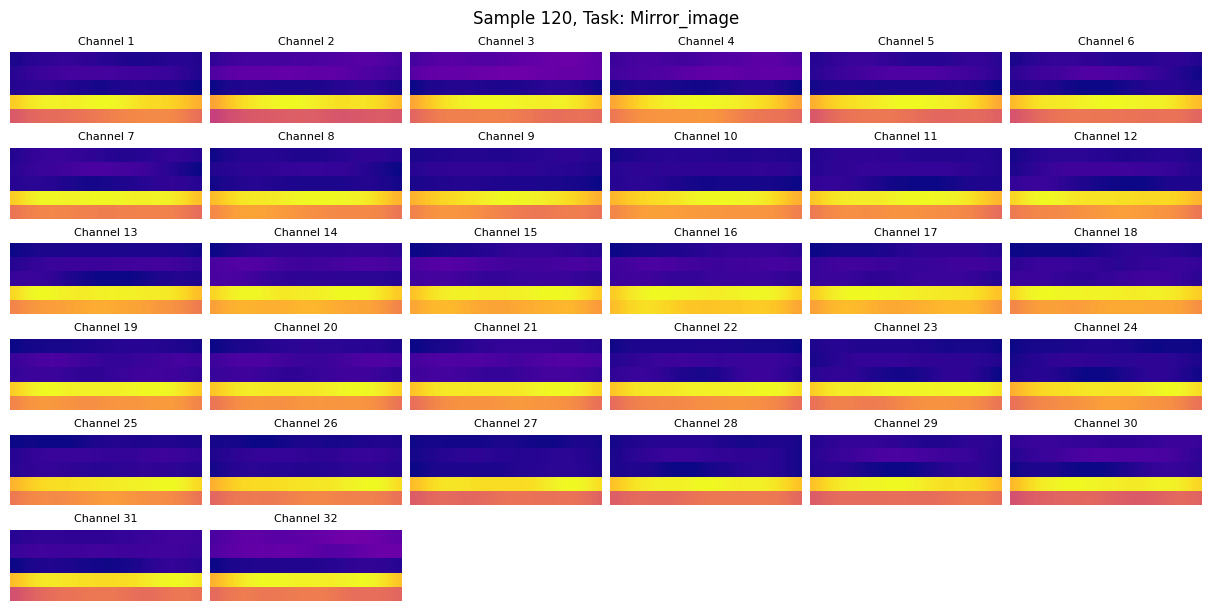

<Figure size 640x480 with 0 Axes>

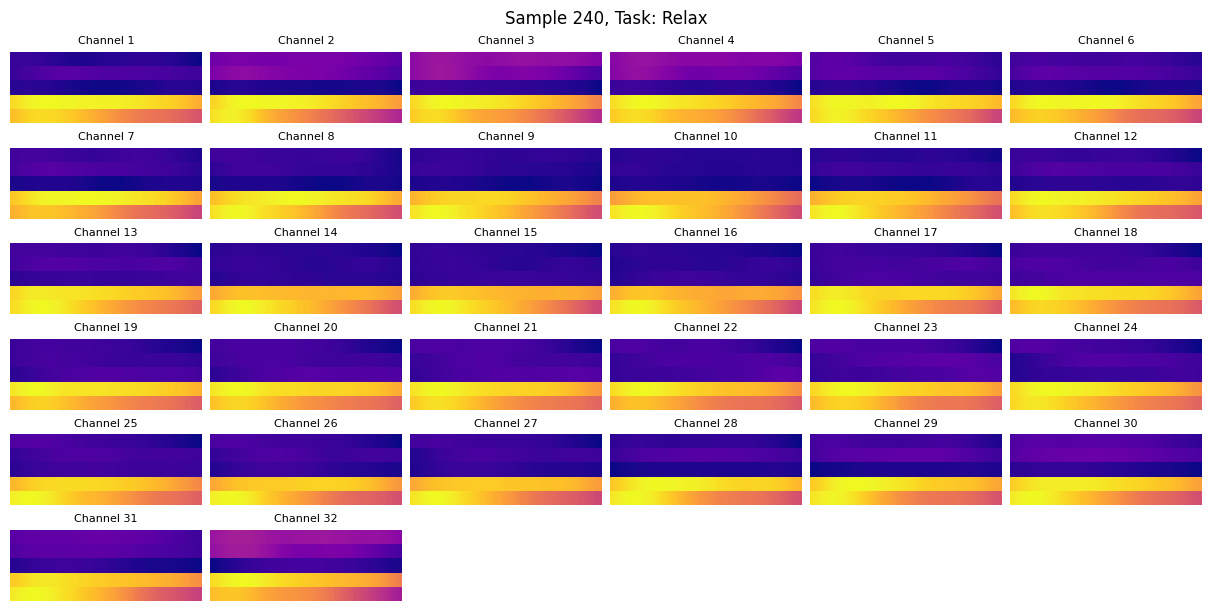

<Figure size 640x480 with 0 Axes>

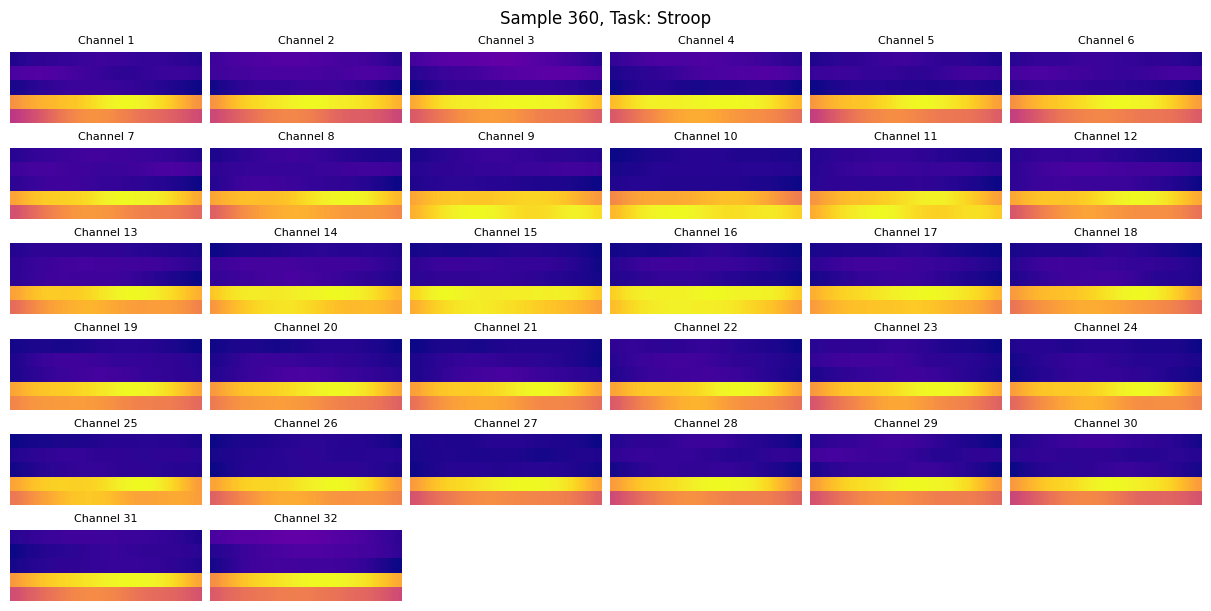

In [6]:
if verbose:
    for label in range(4):
        sampleId = torch.where(y==label)[0][0]
        plot3D(X[sampleId], 
               title=f"Sample {sampleId}, Task: {labelList[y[sampleId]]}",
               titles=lambda i: f"Channel {i+1}",
               size_factor_x=2.0, size_factor_y=1.0,
               fileName=f"fig/sample_{labelList[y[sampleId]]}.png")

## The model

Here are the layers of the model: 
- BatchNorm2d

- Conv2d          
32 to 128 channels, kernel_size of 5, stride 1, padding 2

- Dropout2d       
0.3 probability of channel dropout

- BatchNorm2d

- ReLU

- Conv2d          
128 to 64 channels, kernel_size of 5, stride 1, padding 2

- Dropout2d       
0.2 probability of channel dropout

- BatchNorm2d

- ReLU

- Conv2d          
64 to 32 channels, kernel_size of 5, stride 1, padding 2

- Dropout2d       
0.2 probability of channel dropout

- BatchNorm2d

- ReLU

- Flatten

- Fully-Connected 
32*101*5 to 128 layers

- Dropout         
0.5 probability of neuron dropout

- BatchNorm

- ReLU

- Fully-Connected 
128 to 4 layers

- SoftMax loss


## The training

- Adam optimizer was used
- L2 regularization added to the loss
- Every epoch, the learning rate is reduced by 1%

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU" if torch.cuda.is_available() else "CPU")

model = bigmodel.model(X[0], hyperparams)
loss_fn = nn.CrossEntropyLoss()

classification_model = GoodClassificationModel(model, loss_fn, hyperparams, device, 4)
trainer = GoodTrainer()

def babysitter(goodModel):
    goodModel.hyperparameters['lr'] = 0.99 * goodModel.hyperparameters['lr']

historyLogger = HistoryLogger()

trainer.add_babysitter(babysitter)
trainer.add_logger(lambda res: print_stats(res, print_every=10))
trainer.add_logger(historyLogger)
trainer.add_logger(WandBLogger(hyperparams, labelList, model))

CPU


wandb: Currently logged in as: ulyssedurand (ulyssedurand-ens-de-lyon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
trainer.train(classification_model, dataset, hyperparams['epochs'])

Epoch:    1    | tl: 1.440885, ta: 0.241071    |    vl: 1.391457, va: 0.305556
Epoch:    2    | tl: 1.429670, ta: 0.238095    |    vl: 1.516700, va: 0.305556
Epoch:    3    | tl: 1.408390, ta: 0.276786    |    vl: 1.486750, va: 0.305556


# Results

In [ ]:
res = getTestResults(dataset, classification_model)
print(f" Test accuracy: {res['test_acc']}")

if verbose:
    plot_loss_acc(historyLogger.history, fileNameBase="fig/history")
    test_preds, test_labels = res["test_confusion"]
    plot_confusion_matrix(test_preds, test_labels, labelList, title="Test Confusion Matrix", fileName="fig/test_confusion_matrix.png")
    write_test_acc(res['test_acc'], "fig/test_acc.txt")